# 21 — Deployable head + off-HiRISE map pilot

QA for [PLAN_FM.md](../PLAN_FM.md) §2.6 (DECISIONS.md 2026-06-14). The frozen
recipe (DECISIONS.md 2026-06-12 "Freeze window CLOSED") is **`mlp_ens3` on the
S=32 96-px 3×3-context GeM(p=3) emb-only matrix, target `fa_gt_1e-2`** — LOIO
pooled PR-AUC **0.7832** / prec@5% 0.948 / med per-image AUC 0.7865.

LOIO trains a fresh head per fold; a **map** needs ONE head trained on every
image. `src/modeling/mlp_head.py::DeployableHead` is that head (3-seed ensemble,
one inner-val image rotated per seed for early stopping, mean of the seed
sigmoids), and `src/mapping.py` + `scripts/map_pilot.py` run it over a CTX region
**beyond HiRISE coverage** — the whole point of the project (CLAUDE.md §1).

This notebook shows three things:
1. the deployable recipe card (what got persisted, and that it re-loads);
2. the **honest held-out** truth-vs-model maps at the operating scale (from the
   banked LOIO predictions — the deployable head's own predictions on training
   images would be in-sample and dishonest);
3. the beyond-coverage map the pilot produced.

It is intentionally light — the MLP head needs no ViT checkpoint or GPU; the
heavy embedding map is pre-rendered by the script and displayed here.


In [1]:
import json
from pathlib import Path
import sys

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))
import src.modeling  # noqa: F401  -- Windows DLL bootstrap; must precede numpy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

FIG = REPO / "reports" / "figures"
DEPLOY = REPO / "models" / "deployable"
FROZEN_LOIO = REPO / "models/fang_probe/fw_emb_mlp_ens3_gem96_S32_fa_gt_1e-2/predictions.parquet"
MAP_DIR = REPO / "reports" / "map_pilot"
TILE_PX = 32  # frozen operating scale
print("deployable heads on disk:", sorted(p.name for p in DEPLOY.glob("*") if (p / "recipe.json").exists()))

deployable heads on disk: ['86c51a5dca220f63']


## 1. The deployable head — recipe card + reload check

`DeployableHead.save` persists the 3 seed state-dicts, their feature scalers,
and a self-describing `recipe.json` (the frozen cell id, the LOIO numbers it was
validated by, a config-only `recipe_hash`, and the training-image list). The card
is how a loaded model self-identifies which validated recipe it deploys. We load
it back and confirm it reconstructs 3 members.


In [2]:
from src.modeling.mlp_head import DeployableHead

model_dir = sorted(p for p in DEPLOY.glob("*") if (p / "recipe.json").exists())[-1]
card = json.loads((model_dir / "recipe.json").read_text(encoding="utf-8"))
print("model dir:", model_dir.relative_to(REPO))
for k in ("name", "seeds", "hidden", "dropout", "batch", "recipe_hash", "n_train_images"):
    print(f"  {k}: {card[k]}")
print("  recipe:", json.dumps(card["recipe"]))

head = DeployableHead.load(model_dir)   # CPU/GPU; no ViT checkpoint needed
print(f"\nreloaded OK -> {len(head._members)} seed members, "
      f"recipe_hash={head.recipe_hash()}  (matches card: {head.recipe_hash() == card['recipe_hash']})")

model dir: models\deployable\86c51a5dca220f63
  name: deployable_mlp_ens3
  seeds: [0, 1, 2]
  hidden: [256, 64]
  dropout: 0.2
  batch: 4096
  recipe_hash: 86c51a5dca220f63
  n_train_images: 38
  recipe: {"cell": "fw_emb_mlp_ens3_gem96_S32_fa_gt_1e-2", "target_id": "fa_gt_1e-2", "scale_idx": 2, "tile_size_px": 32, "input_px": 96, "pool": "gem", "embedding": "fang_vit_b16_gem_p3", "loio_pooled_pr_auc": 0.7832, "loio_med_per_image_auc": 0.7865}



reloaded OK -> 3 seed members, recipe_hash=86c51a5dca220f63  (matches card: True)


## 2. Honest held-out skill — truth vs model at the operating scale (S=32)

Same presentation as [notebook 20](20_fang_vit_probe.ipynb) §6 and
[docs/classification_slimmer.md](../docs/classification_slimmer.md) Fig 5, but
for the **frozen operating recipe** (emb-only, S=32, 160 m tiles — the 4×-finer
map the deployable head produces), and the predictions are the **banked LOIO
held-out** scores, so each image was scored by a model that never trained on it.

Per image: LEFT = truth (tiles with `fractional_area > 1e-2` highlighted),
RIGHT = the model's rich calls at **matched budget** (top-N by held-out score,
N = the true rich count) — so the question is purely *whether it picks the same
tiles*. Exemplars are the slimmer-doc Fig 5 pair: a very-rich image and the
former **anti-signal** image ESP_046328_2180 (the 5-feature slim model scored it
AUC **0.344 — worse than chance**; the FM recipe's AUC is in the panel title).


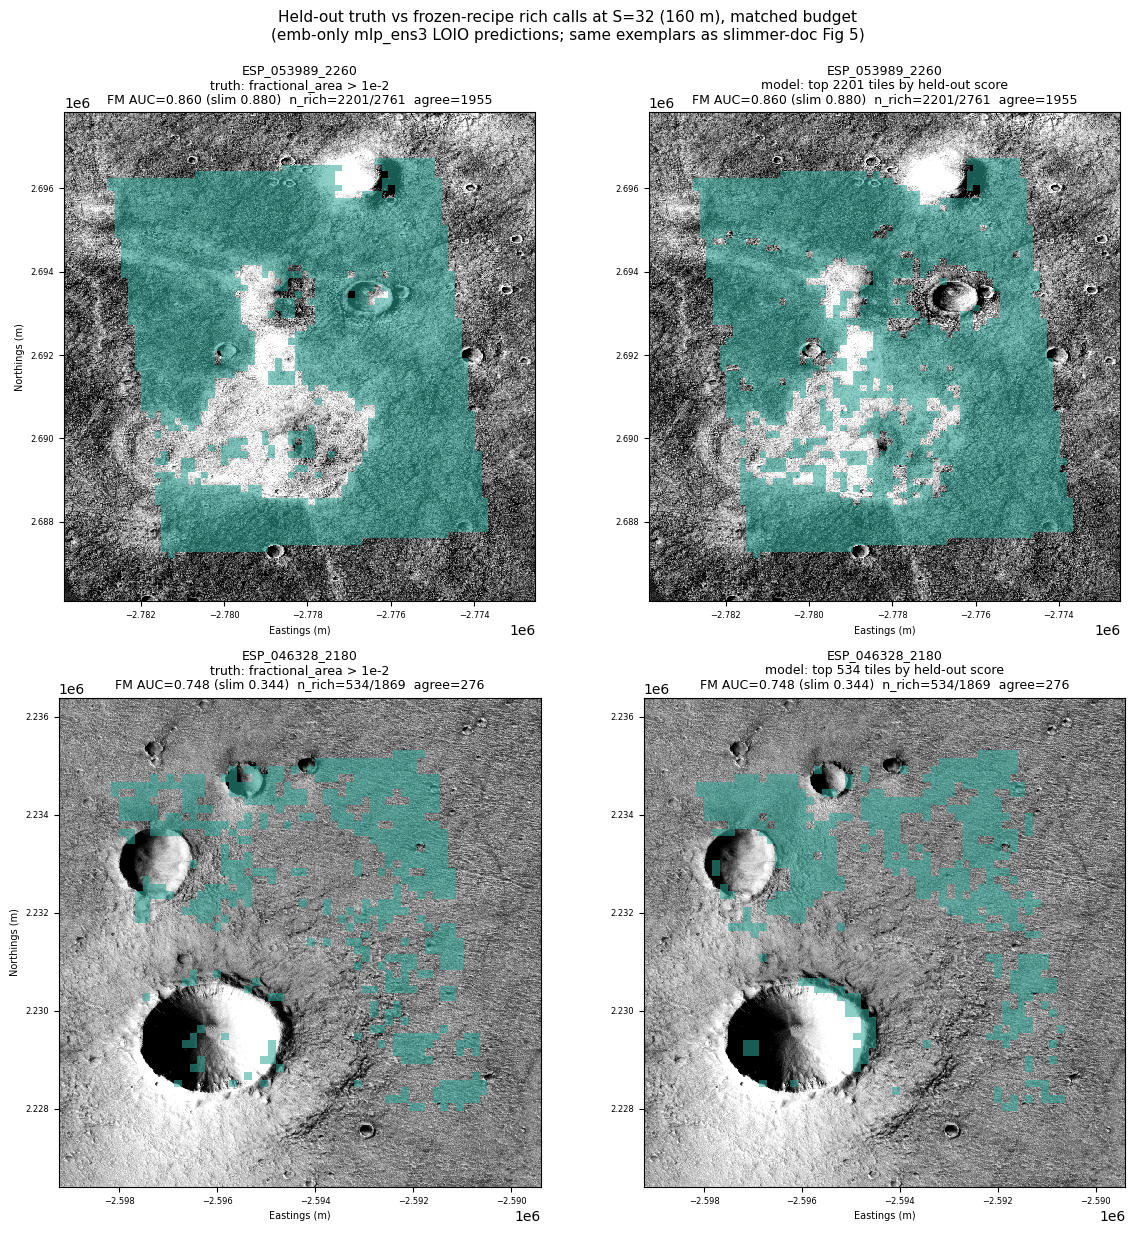

In [3]:
import rasterio
from sklearn.metrics import roc_auc_score

EXEMPLARS = ["ESP_053989_2260", "ESP_046328_2180"]  # slimmer-doc Fig 5 pair
SLIM_AUC = {"ESP_053989_2260": 0.880, "ESP_046328_2180": 0.344}  # 5-feature slim baseline
preds = pd.read_parquet(FROZEN_LOIO)

fig, axes = plt.subplots(2, 2, figsize=(12, 12.5))
for r, obs in enumerate(EXEMPLARS):
    side = json.loads((REPO / f"dataset_v2/labels/{obs}.json").read_text(encoding="utf-8"))
    with rasterio.open(side["ctx_window_tif"]) as src:
        win = src.read(1).astype(np.uint8)
        b = src.bounds
    extent = (b.left, b.right, b.bottom, b.top)
    row0, col0 = int(side["mosaic_row_origin"]), int(side["mosaic_col_origin"])

    df = preds[preds.obs_id == obs]
    n_rich = int(df.y_true.sum())
    auc = roc_auc_score(df.y_true, df.y_pred)
    called = set(df.nlargest(n_rich, "y_pred")[["ti", "tj"]].itertuples(index=False, name=None))
    truth = set(df[df.y_true == 1][["ti", "tj"]].itertuples(index=False, name=None))
    agree = len(called & truth)

    lo, hi = np.percentile(win[win > 0], [2, 98])
    for c, (tiles, kind) in enumerate(((truth, "truth: fractional_area > 1e-2"),
                                       (called, f"model: top {n_rich} tiles by held-out score"))):
        mask = np.zeros(win.shape, dtype=np.uint8)
        for ti, tj in tiles:
            rw, cw = int(ti) * TILE_PX - row0, int(tj) * TILE_PX - col0
            if 0 <= rw < win.shape[0] and 0 <= cw < win.shape[1]:
                mask[rw: rw + TILE_PX, cw: cw + TILE_PX] = 1
        ax = axes[r, c]
        ax.imshow(win, cmap="gray", vmin=lo, vmax=hi, extent=extent, interpolation="nearest")
        overlay = np.ma.masked_where(mask == 0, mask)
        ax.imshow(overlay, cmap=plt.matplotlib.colors.ListedColormap(["#2ca89a"]),
                  alpha=0.55, extent=extent, interpolation="nearest")
        ax.set_title(f"{obs}\n{kind}\nFM AUC={auc:.3f} (slim {SLIM_AUC[obs]:.3f})  "
                     f"n_rich={n_rich}/{len(df)}  agree={agree}", fontsize=9)
        ax.tick_params(labelsize=6)
        ax.set_xlabel("Eastings (m)", fontsize=7)
        if c == 0:
            ax.set_ylabel("Northings (m)", fontsize=7)
fig.suptitle("Held-out truth vs frozen-recipe rich calls at S=32 (160 m), matched budget\n"
             "(emb-only mlp_ens3 LOIO predictions; same exemplars as slimmer-doc Fig 5)", fontsize=11)
fig.tight_layout()
fig.savefig(FIG / "21_deployable_truth_vs_model.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. The off-HiRISE map — predicting where there is no HiRISE

A Murray Lab CTX tile is 4°×4° (~237 km) while a HiRISE footprint is ~6 km, so
almost all of any cohort tile is **beyond HiRISE coverage**. `scripts/map_pilot.py`
windows a cohort tile *adjacent to but not overlapping* one image's footprint
(reusing a cached tile zip — no download), then runs the productized path:

```
read_tile_window → FangEmbedder.embed_window → DeployableHead.predict
  → tiles_to_raster → 160 m GeoTIFF (tile CRS) + PNG
```

The grid is anchored to the **parent Murray-tile pixel origin**, so `(ti, tj)` are
unique within the tile; `tile_origin_transform` reconstructs that origin for
georeferencing (passing the window affine straight into the coarsened transform
double-counts the read offset — a bug caught here by a post-render bounds check
and regression-tested in `tests/test_mapping.py`).

The figure below is the pilot output (E4_N44, east of ESP_055253_2245). LEFT =
CTX 5 m/px; MIDDLE = P(boulder-rich) at 160 m; RIGHT = rich/poor at P≥0.5. The
region reads as mostly **poor** — the honest result for smooth plains beyond a
rich image's footprint — but the probability field is **not** flat: elevated
patches track the rougher CTX texture, i.e. the model responds to terrain.


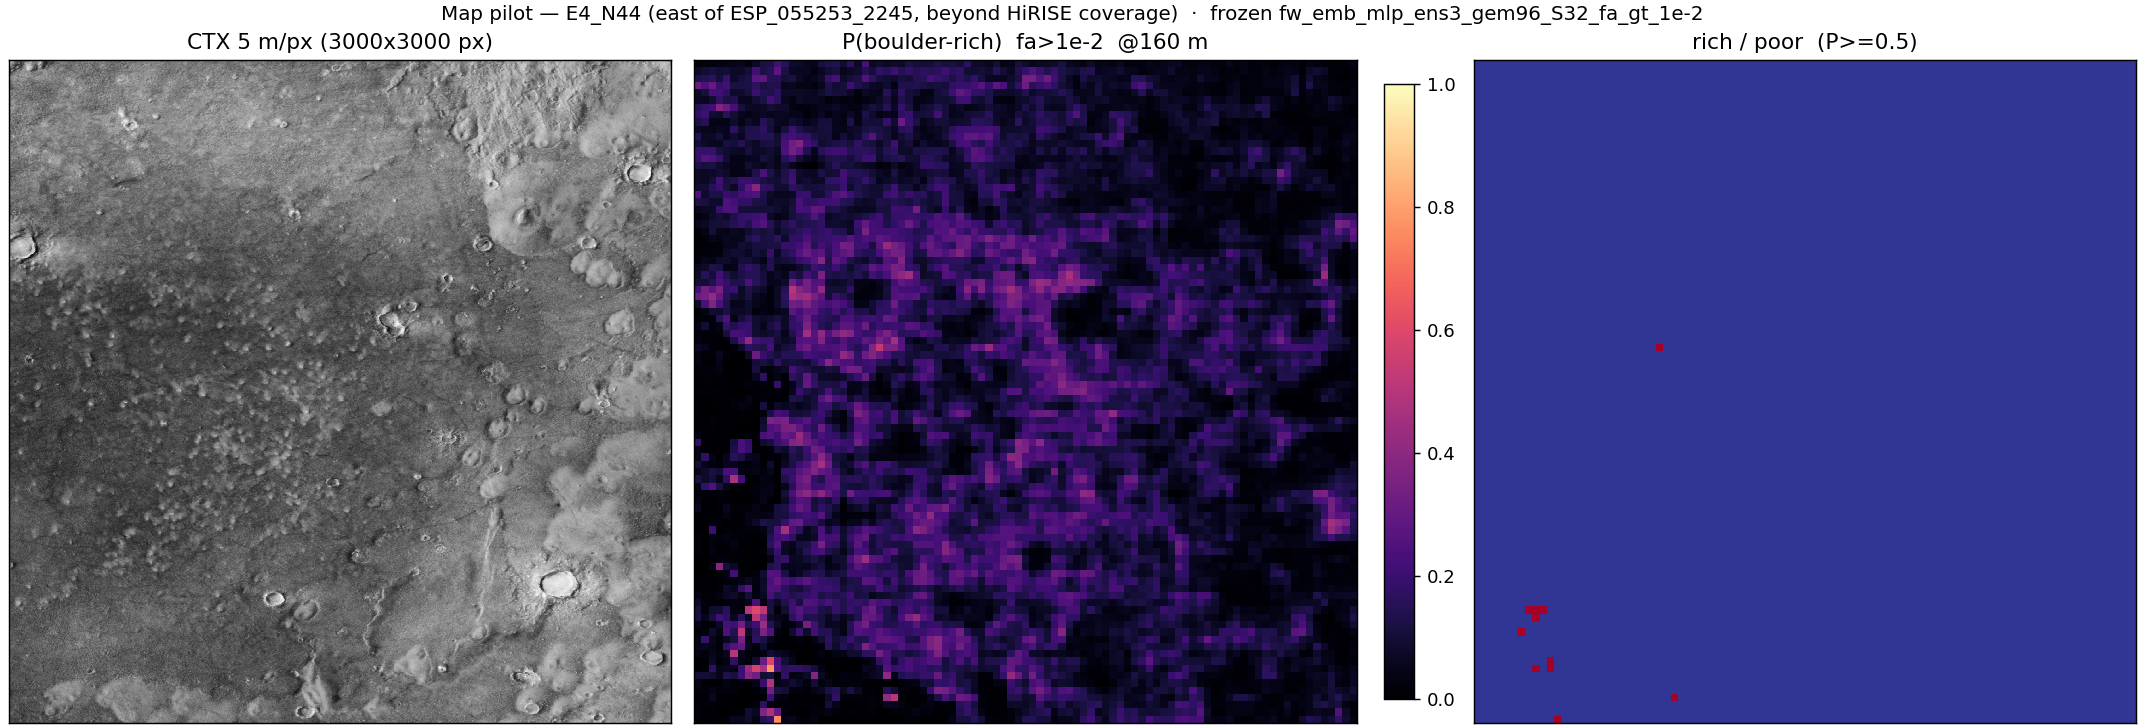

{
  "obs_id": "ESP_055253_2245",
  "murray_tile": "E4_N44",
  "placement": "east",
  "window_offset_rowcol": [
    43790,
    10828
  ],
  "win_px": 3000,
  "tile_px": 32,
  "model_dir": "models\\deployable\\86c51a5dca220f63",
  "recipe_hash": "86c51a5dca220f63",
  "n_tiles": 8281,
  "n_predicted": 8281,
  "n_nodata_masked": 0,
  "rich_share_at_0p5": 0.001328341987682647
}


In [4]:
pngs = sorted(FIG.glob("map_pilot_*_east.png")) or sorted(FIG.glob("map_pilot_*.png"))
if not pngs:
    print("No map-pilot figure found. Generate it first:\n"
          "  conda run -n geospatial python scripts/map_pilot.py --obs-id ESP_055253_2245 --win-px 3000")
else:
    stem = pngs[-1].stem
    display(Image(filename=str(pngs[-1]), width=1100))
    meta = MAP_DIR / f"{stem}.json"
    if meta.exists():
        print(json.dumps(json.loads(meta.read_text(encoding='utf-8')), indent=2))

In [5]:
# Confirm the GeoTIFF is real geospatial output (CRS, 160 m pixels, finite predictions).
import rasterio

tifs = sorted(MAP_DIR.glob("map_pilot_*.tif"))
if tifs:
    with rasterio.open(tifs[-1]) as s:
        a = s.read(1)
        fin = np.isfinite(a)
        print(f"{tifs[-1].name}")
        print(f"  shape={s.shape}  pixel={s.transform.a:.1f} m  crs={s.crs.to_string()[:46]}...")
        print(f"  predicted tiles={int(fin.sum())}/{a.size}  "
              f"mean P(rich)={np.nanmean(a):.3f}  rich@0.5={float((a[fin] >= 0.5).mean()):.3f}")
        b = s.bounds
        print(f"  bounds (m): E[{b.left:.0f},{b.right:.0f}] N[{b.bottom:.0f},{b.top:.0f}]")

map_pilot_E4_N44_ESP_055253_2245_east.tif
  shape=(91, 91)  pixel=160.0 m  crs=PROJCS["Mars_2015_Ocentric_Equirectangular_clo...
  predicted tiles=8281/8281  mean P(rich)=0.117  rich@0.5=0.001
  bounds (m): E[291499,306058] N[2611427,2625987]


## 4. Disposition

§2.6 is **done**: the frozen recipe is a single persisted all-data model
(`models/deployable/`), and the off-HiRISE inference path runs end to end into a
georeferenced 160 m map. The held-out maps in §2 show the recipe picks the right
tiles at the operating scale — including on the former anti-signal image.

Honesty notes carried with this:
- The map currently has **no reliability layer** — every tile is shown with equal
  confidence. The next build (PLAN_FM §2.7) is a per-tile embedding-novelty score
  ("is this CTX texture like what I trained on?"), validated against where the
  frozen recipe's *own* per-image AUC is weak.
- The deployable head inherits the **LOIO estimate as a conservative bound** (more
  data ≥ less); a true held-out number waits on the §2.3 confirmation cohort
  (Brian's BoulderNet runs on the 23 expansion ObsIds).
- Standing FM caveat: transductive pretraining (the ViT saw test *pixels*, never
  labels) — deployment is Murray-mosaic inference, in-corpus everywhere.
- Cross-tile scale-out is trivial by design but not built: combine = raster
  placement once the Murray-tile id is carried alongside `(ti, tj)`.

To regenerate: `python notebooks/_build_21.py` then `nbconvert --execute`; the map
itself via `python scripts/map_pilot.py`.
